In [6]:
# pip install torch torchvision scikit-learn matplotlib seaborn tqdm

import os, random, copy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset, Subset
import torchvision
import torchvision.transforms as T
from torchvision.models import resnet18

from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix,
    roc_curve, classification_report
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


In [7]:
DATA_ROOT = Path('./data')
SAMPLES_PER_PARTITION = 5000

base_transform = T.Compose([
    T.ToTensor(),
])

mnist_train = torchvision.datasets.MNIST(DATA_ROOT, train=True,  download=True, transform=base_transform)
mnist_test  = torchvision.datasets.MNIST(DATA_ROOT, train=False, download=True, transform=base_transform)
print(f'Train: {len(mnist_train)}, Test: {len(mnist_test)}')

Train: 60000, Test: 10000


In [8]:
def attack_gaussian_noise(img: torch.Tensor, std: float = 0.15) -> torch.Tensor:
    return (img + torch.randn_like(img) * std).clamp(0, 1)


def attack_salt_pepper(img: torch.Tensor, prob: float = 0.10) -> torch.Tensor:
    out = img.clone()
    mask = torch.rand_like(img)
    out[mask < prob / 2]  = 0.0
    out[mask > 1 - prob / 2] = 1.0
    return out


def attack_geometric(img: torch.Tensor, magnitude: float = 6.0) -> torch.Tensor:
    transform = T.ElasticTransform(alpha=magnitude * 50, sigma=magnitude)
    return transform(img)


def attack_blending(img: torch.Tensor, alpha: float = 0.25) -> torch.Tensor:
    pattern = torch.rand_like(img)
    return ((1 - alpha) * img + alpha * pattern).clamp(0, 1)


def attack_trigger(img: torch.Tensor, trigger_size: int = 5) -> torch.Tensor:
    out = img.clone()
    H, W = img.shape[-2], img.shape[-1]
    x = random.randint(0, W - trigger_size)
    y = random.randint(0, H - trigger_size)
    out[:, y:y+trigger_size, x:x+trigger_size] = 1.0
    return out


ATTACKS = {
    'attack_a': attack_gaussian_noise,
    'attack_b': attack_salt_pepper,
    'attack_c': attack_geometric,
    'attack_d': attack_blending,
    'attack_e': attack_trigger,
}

In [9]:
class TransformSubset(Dataset):
    def __init__(self, subset, attack_fn=None, is_poisoned=0):
        self.subset = subset
        self.attack_fn = attack_fn
        self.is_poisoned = is_poisoned

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.attack_fn:
            img = self.attack_fn(img)
        return img, label, self.is_poisoned

def create_joined_poisoned_dataset(base_dataset, attack_fn):
    
    clean_subset = TransformSubset(base_dataset, attack_fn=None, is_poisoned=0)
    poison_subset = TransformSubset(base_dataset, attack_fn=attack_fn, is_poisoned=1)
    
    # Join the clean and poisoned data
    return ConcatDataset([clean_subset, poison_subset])


## Clean + Attack -> Different Attack

In [10]:
# !pip install monai pytorch-lightning

import pytorch_lightning as pl
import torch.nn.functional as F
from pytorch_lightning import Trainer
from monai.networks.nets import UNet
import os

class PoisonClassifier(pl.LightningModule):
    def __init__(self, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        
        # We use MONAI's UNet. Since UNet is typically for segmentation,
        # we will use the output and globally average pool it to produce a single classification logit.
        self.unet = UNet(
            spatial_dims=2,
            in_channels=1,
            out_channels=1,       # 1 channel for binary classification feature map
            channels=(16, 32, 64),
            strides=(2, 2)
        )
        self.loss_fn = nn.BCEWithLogitsLoss()

    def forward(self, x):
        # x is [B, 1, 28, 28] for MNIST
        out = self.unet(x) # Out is [B, 1, 28, 28]
        # Pool to [B, 1, 1, 1] then flatten to [B]
        logits = F.adaptive_avg_pool2d(out, 1).view(-1)
        return logits

    def training_step(self, batch, batch_idx):
        imgs, labels, is_poisoned = batch
        logits = self(imgs)
        loss = self.loss_fn(logits, is_poisoned.float())
        self.log('train_loss', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        imgs, labels, is_poisoned = batch
        logits = self(imgs)
        loss = self.loss_fn(logits, is_poisoned.float())
        
        preds = (torch.sigmoid(logits) > 0.5).long()
        acc = (preds == is_poisoned).float().mean()
        
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)

    def test_step(self, batch, batch_idx):
        imgs, labels, is_poisoned = batch
        logits = self(imgs)
        loss = self.loss_fn(logits, is_poisoned.float())
        
        preds = (torch.sigmoid(logits) > 0.5).long()
        acc = (preds == is_poisoned).float().mean()
        
        self.log('test_loss', loss, prog_bar=True)
        self.log('test_acc', acc, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

models = {}

os.makedirs('saved_models', exist_ok=True)

for attack_name, attack_fn in ATTACKS.items():
    print(f"Training model for {attack_name}")
    
    # Create dataset for this attack
    poisoned_train_ds_attack = create_joined_poisoned_dataset(mnist_train, attack_fn)
    
    # Split train dataset into train and validation (80/20 split)
    train_size = int(0.8 * len(poisoned_train_ds_attack))
    val_size = len(poisoned_train_ds_attack) - train_size
    train_split, val_split = torch.utils.data.random_split(poisoned_train_ds_attack, [train_size, val_size])

    # Initialize DataLoaders
    train_loader = DataLoader(train_split, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_split, batch_size=64, shuffle=False)

    # Initialize Model and Trainer
    model = PoisonClassifier(lr=1e-3)
    trainer = Trainer(
        max_epochs=10,
        accelerator='auto',
        devices=1,
        log_every_n_steps=10,
        enable_model_summary=False,
    )

    # Start training
    trainer.fit(model, train_loader, val_loader)
    
    # Save the model
    model_path = os.path.join('saved_models', f"model_{attack_name}.ckpt")
    trainer.save_checkpoint(model_path)
    
    models[attack_name] = model

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 3080') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training model for attack_a


Output()

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec,
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

...

`weights_only` was not set, defaulting to `False`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

Training model for attack_e


`Trainer.fit` stopped: `max_epochs=10` reached.


`weights_only` was not set, defaulting to `False`.


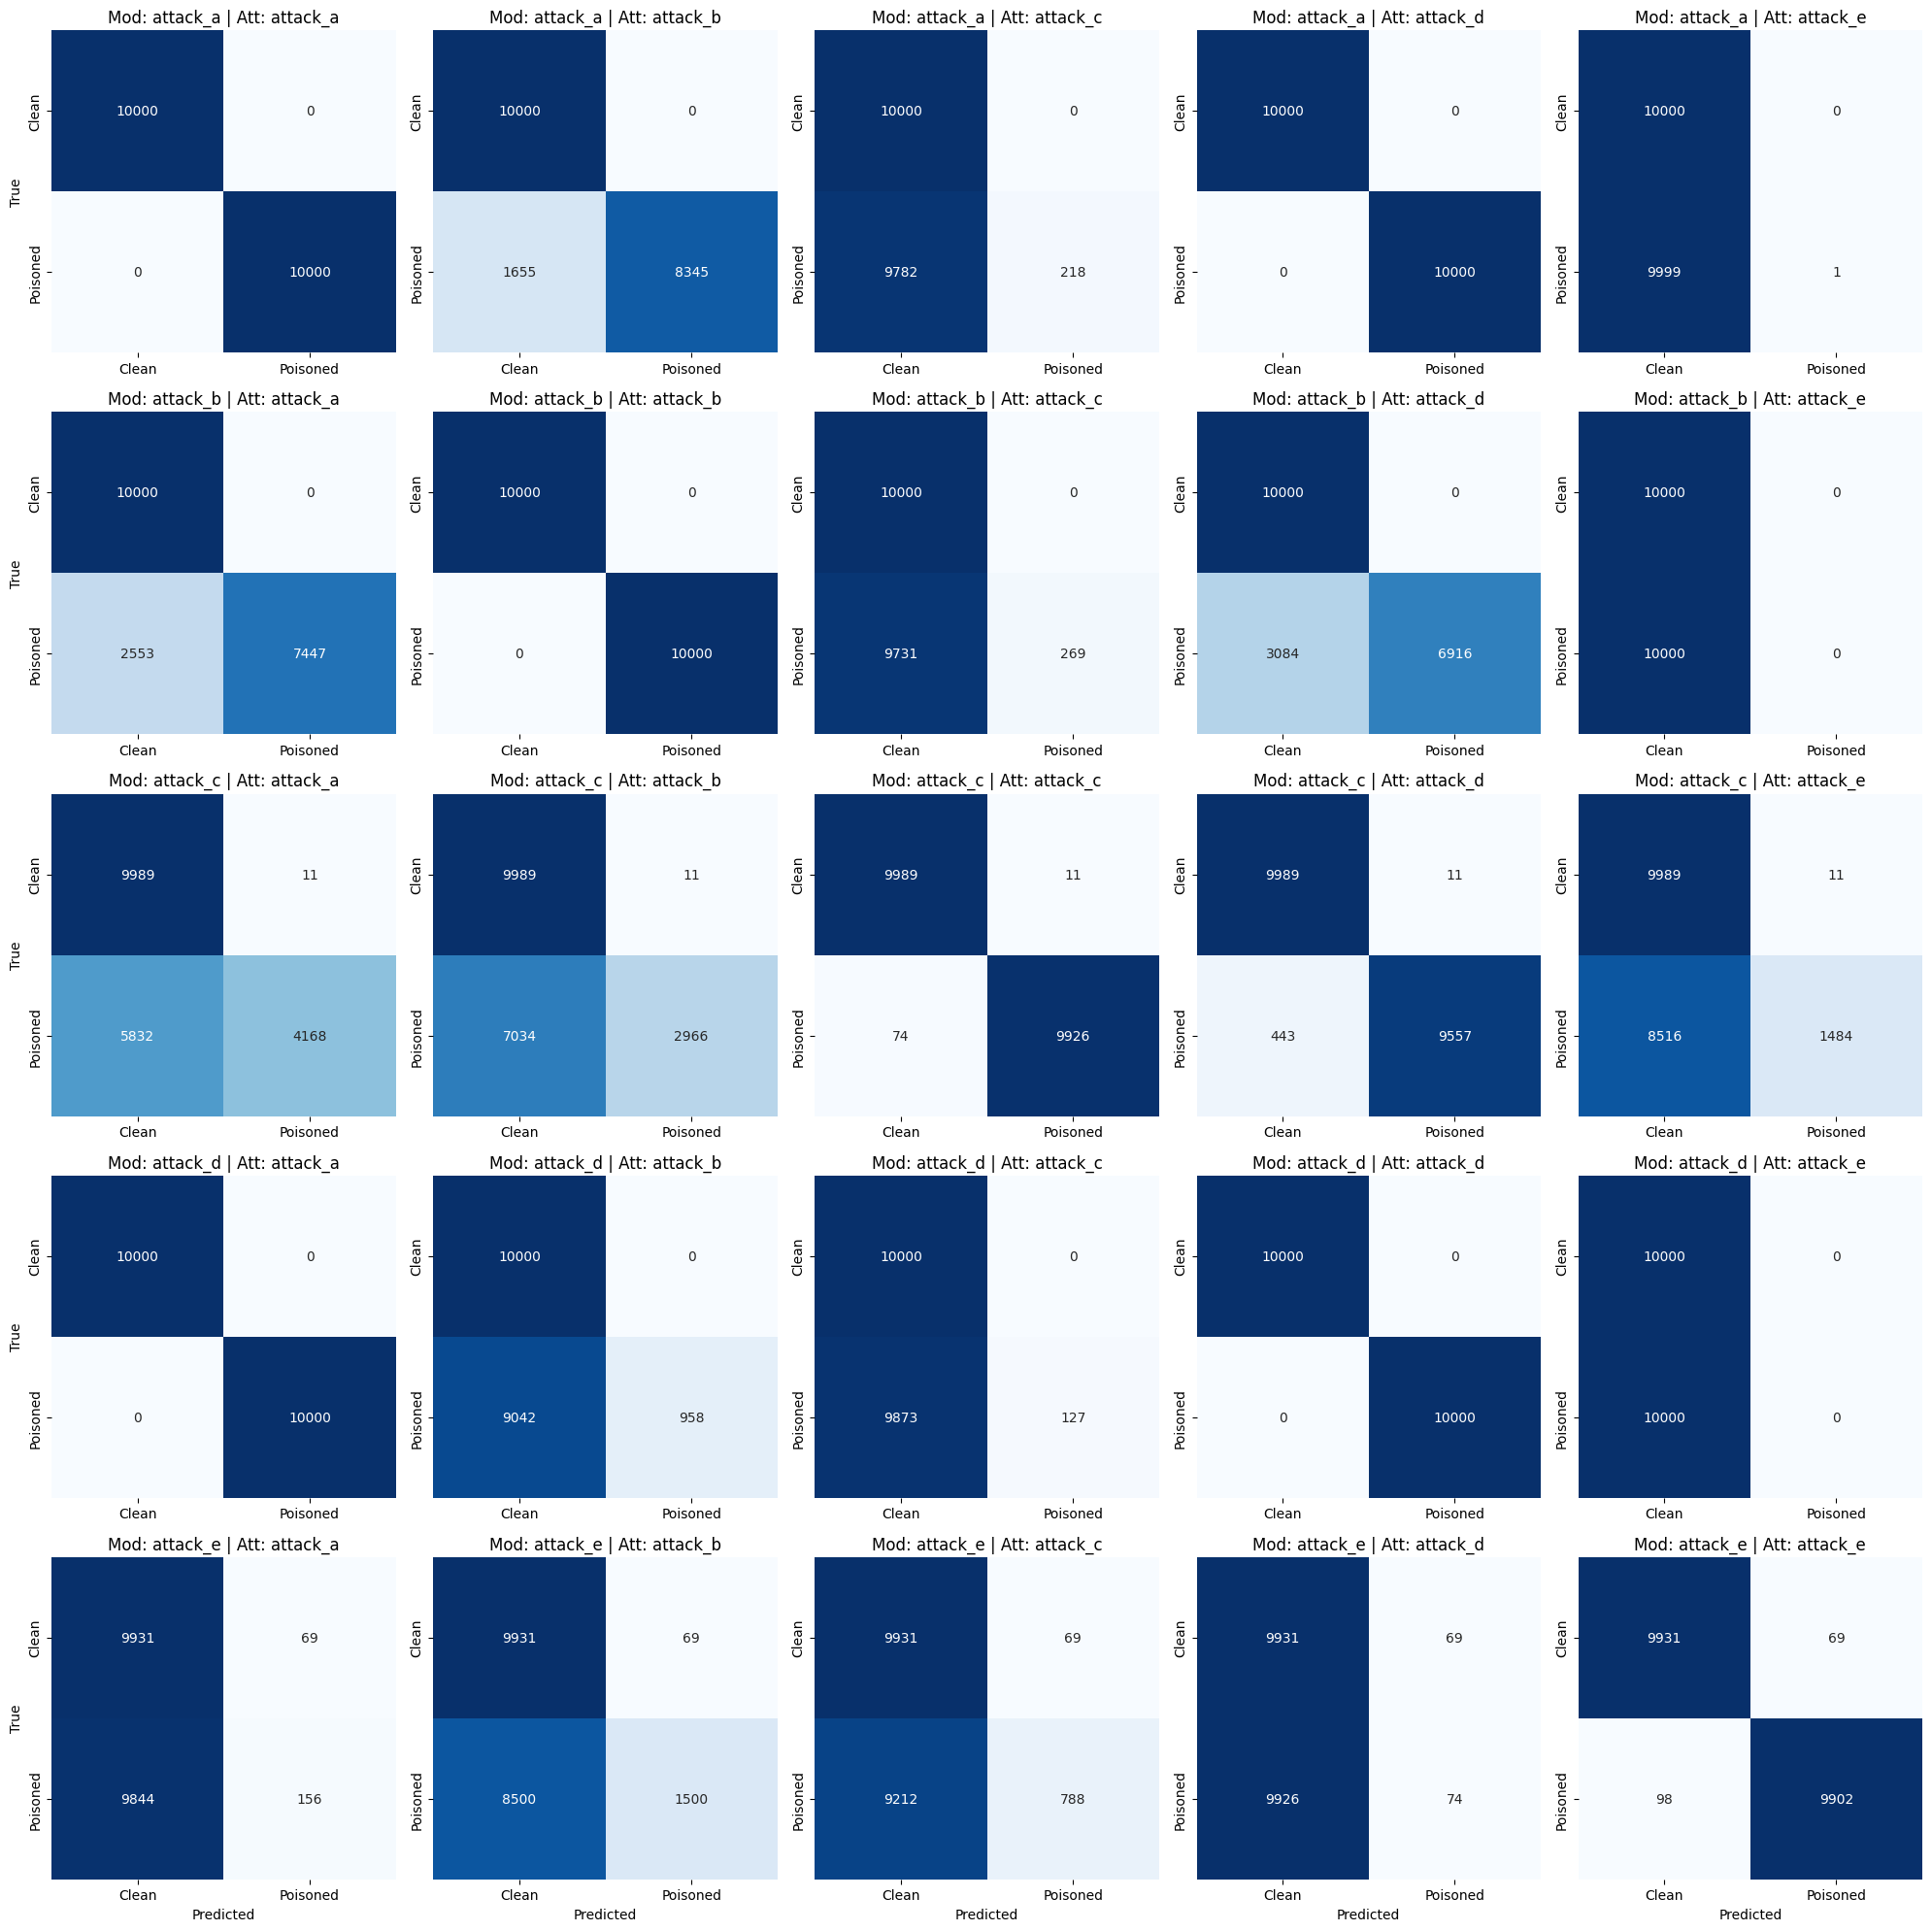

In [11]:
fig, axes = plt.subplots(len(ATTACKS), len(ATTACKS), figsize=(4 * len(ATTACKS), 4 * len(ATTACKS)))

for i, (model_name, model) in enumerate(models.items()):
    model.eval()
    for j, (attack_name, attack_fn) in enumerate(ATTACKS.items()):
        # Create test dataset with the specific attack
        test_ds = create_joined_poisoned_dataset(mnist_test, attack_fn)
        test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
        
        all_preds_attack = []
        all_poisoned_attack = []
        
        with torch.no_grad():
            for imgs, labels, is_poisoned in test_loader:
                imgs = imgs.to(model.device)
                logits = model(imgs)
                preds = (torch.sigmoid(logits) > 0.5).long().cpu()
                
                all_preds_attack.extend(preds.numpy())
                all_poisoned_attack.extend(is_poisoned.numpy())
                
        cm = confusion_matrix(all_poisoned_attack, all_preds_attack)
        ax = axes[i, j]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                    xticklabels=['Clean', 'Poisoned'], 
                    yticklabels=['Clean', 'Poisoned'])
        ax.set_title(f"Mod: {model_name} | Att: {attack_name}")
        if i == len(ATTACKS) - 1:
            ax.set_xlabel("Predicted")
        if j == 0:
            ax.set_ylabel("True")

plt.tight_layout()
plt.show()

## Trening na A₁…Aₙ, test na Aₙ₊₁

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec,
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

...

`weights_only` was not set, defaulting to `False`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


--- Training model holding out (unseen): attack_e ---


`Trainer.fit` stopped: `max_epochs=10` reached.


`weights_only` was not set, defaulting to `False`.


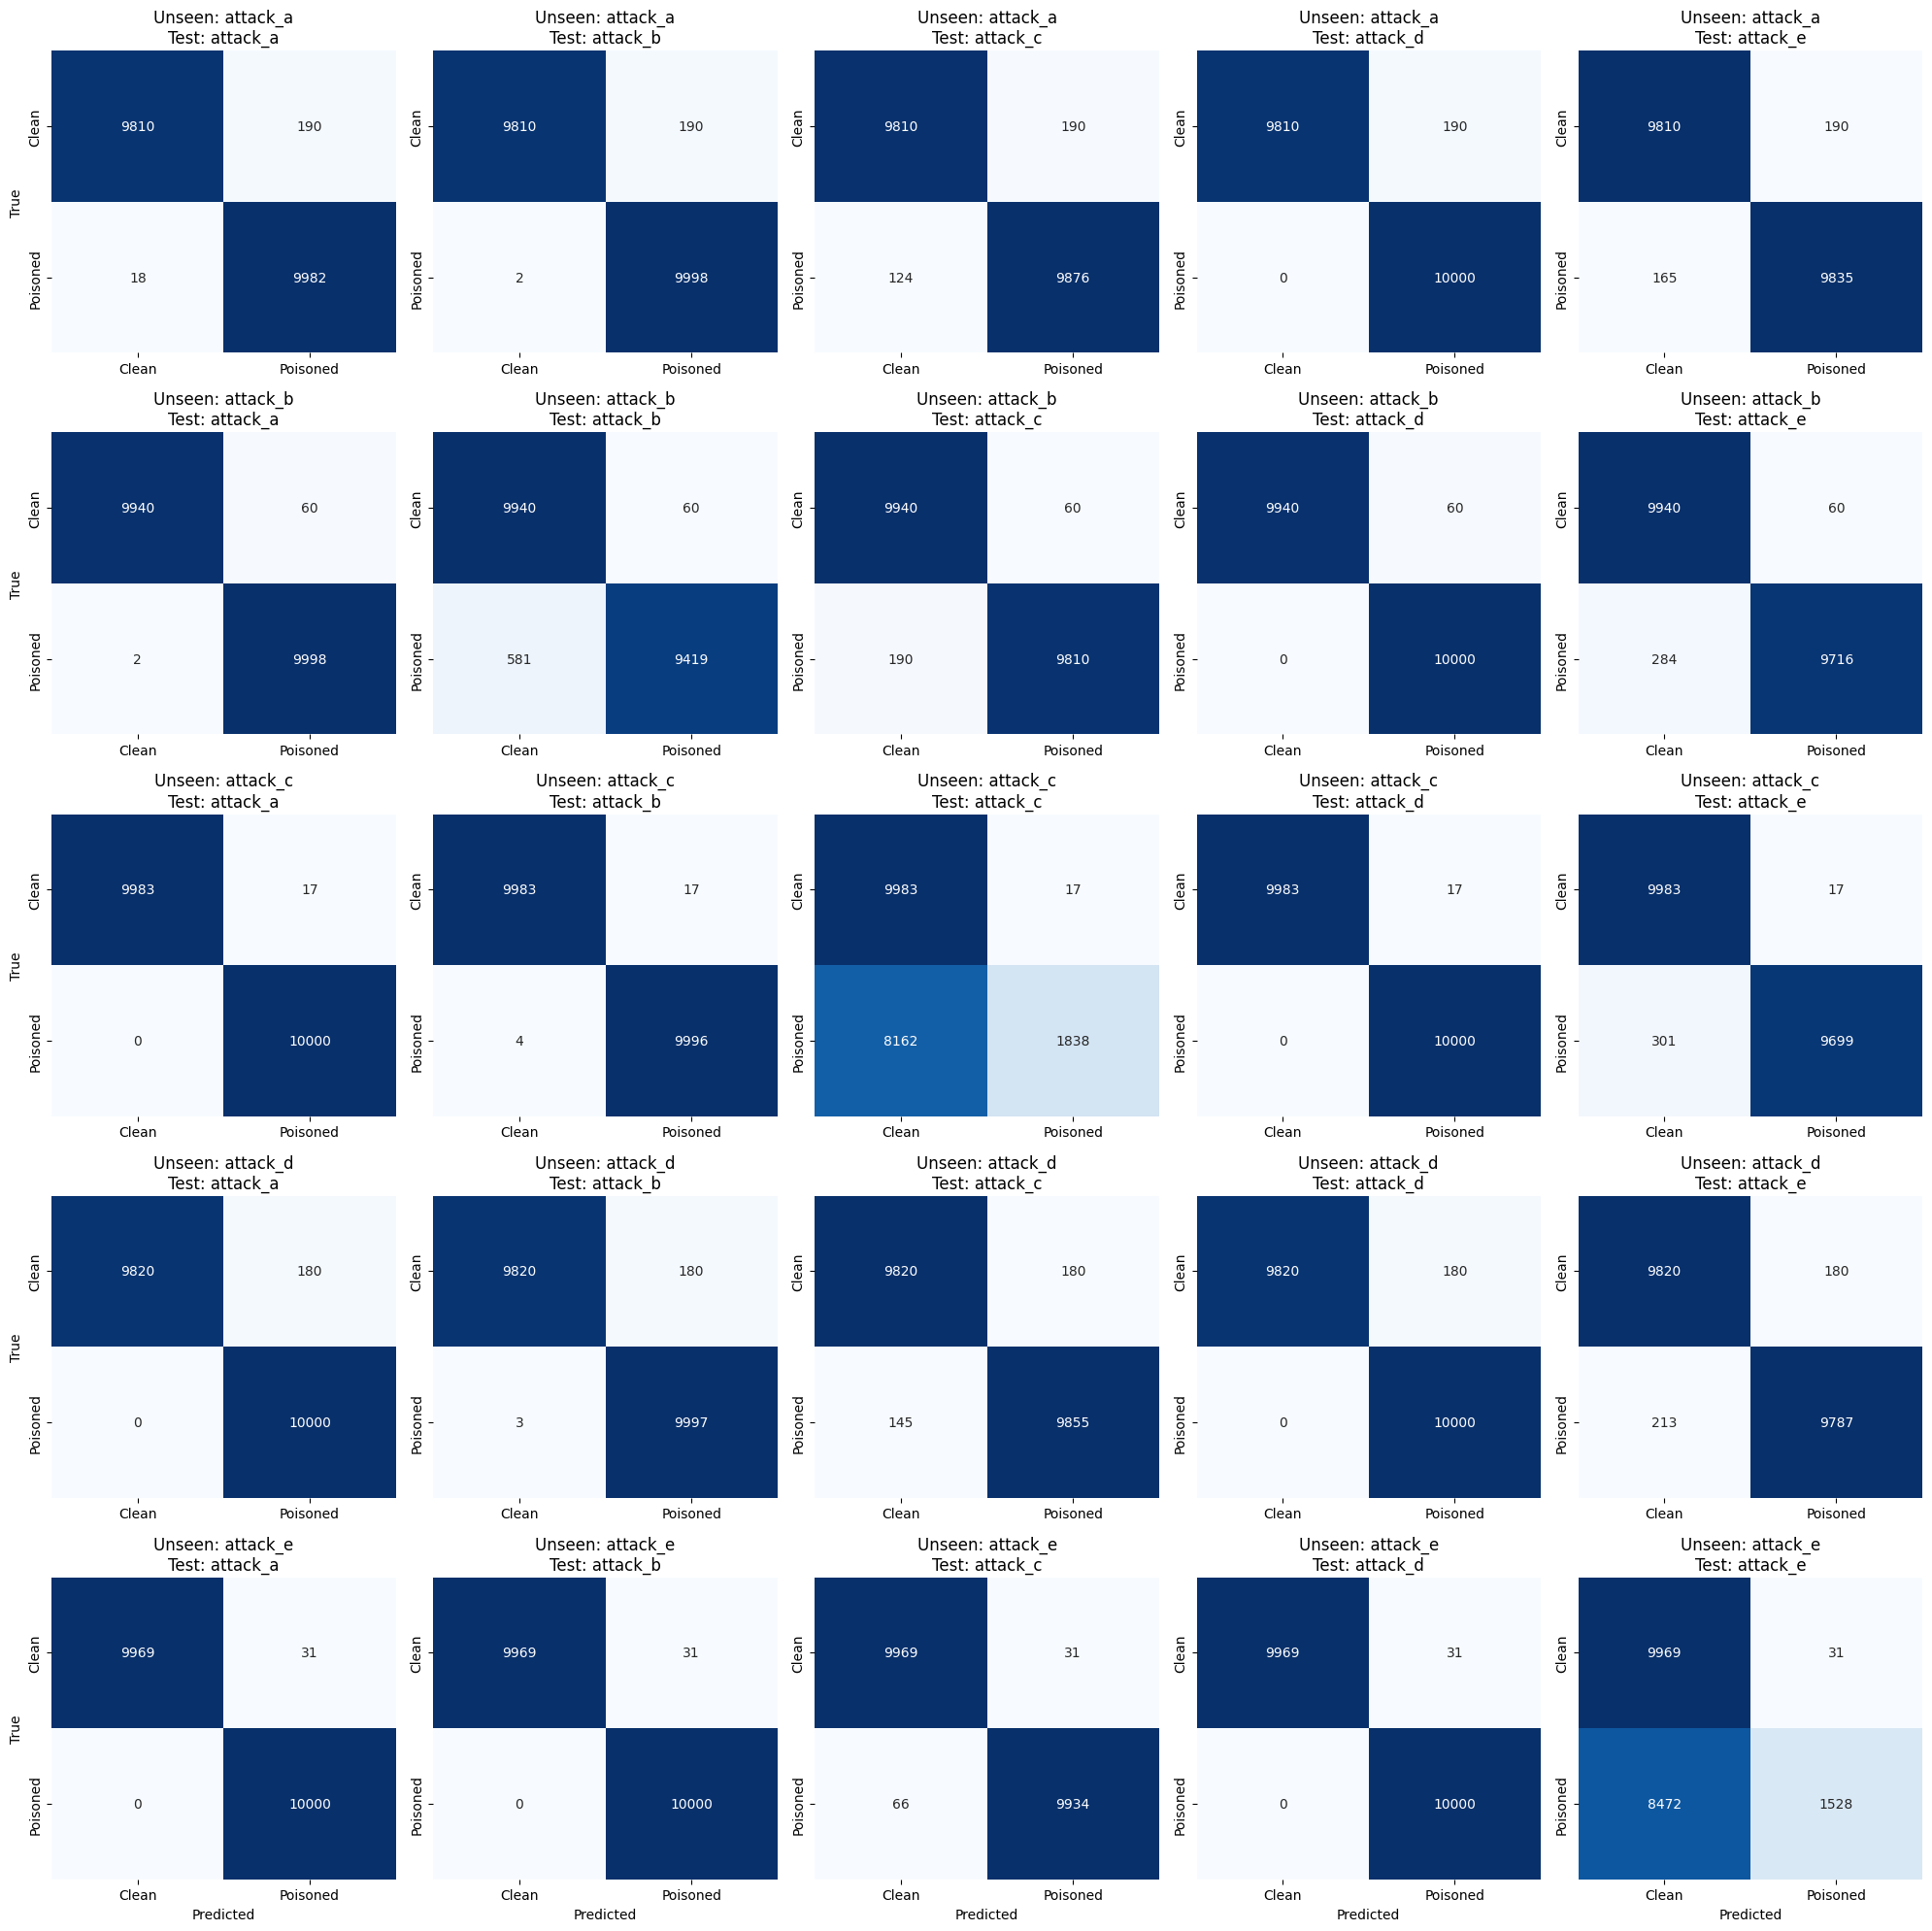

In [12]:
import seaborn as sns
import os

class RandomAttackSubset(Dataset):
    def __init__(self, subset, attack_fns, is_poisoned=0):
        self.subset = subset
        self.attack_fns = attack_fns
        self.is_poisoned = is_poisoned

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.attack_fns and self.is_poisoned == 1:
            attack_fn = random.choice(self.attack_fns)
            img = attack_fn(img)
        return img, label, self.is_poisoned

# 50% clean, 50% poisoned (from multiple attacks)
def create_mixed_poisoned_dataset(base_dataset, attack_fns):
    clean_subset = TransformSubset(base_dataset, attack_fn=None, is_poisoned=0)
    poison_subset = RandomAttackSubset(base_dataset, attack_fns=attack_fns, is_poisoned=1)
    return ConcatDataset([clean_subset, poison_subset])

mixed_models = {}
os.makedirs('saved_models', exist_ok=True)

# Train a model for each leave-one-out combination of attacks
for held_out_attack_name in ATTACKS.keys():
    train_attack_names = [k for k in ATTACKS.keys() if k != held_out_attack_name]
    
    print(f"\n--- Training model holding out (unseen): {held_out_attack_name} ---")
    
    train_attack_fns = [ATTACKS[k] for k in train_attack_names]
    mixed_train_ds = create_mixed_poisoned_dataset(mnist_train, train_attack_fns)

    train_size = int(0.8 * len(mixed_train_ds))
    val_size = len(mixed_train_ds) - train_size
    train_split, val_split = torch.utils.data.random_split(mixed_train_ds, [train_size, val_size])

    train_loader = DataLoader(train_split, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_split, batch_size=64, shuffle=False)

    mixed_model = PoisonClassifier(lr=1e-3)
    trainer_mixed = Trainer(
        max_epochs=10,
        accelerator='auto',
        devices=1,
        log_every_n_steps=10,
        enable_model_summary=False,
    )

    trainer_mixed.fit(mixed_model, train_loader, val_loader)
    
    mixed_model_path = os.path.join('saved_models', f"model_mixed_no_{held_out_attack_name}.ckpt")
    trainer_mixed.save_checkpoint(mixed_model_path)
    
    mixed_models[held_out_attack_name] = mixed_model


# Plotting evaluation grid
fig, axes = plt.subplots(len(mixed_models), len(ATTACKS), figsize=(4 * len(ATTACKS), 4 * len(mixed_models)))

for i, (held_out_name, model) in enumerate(mixed_models.items()):
    model.eval()
    for j, (test_attack_name, test_attack_fn) in enumerate(ATTACKS.items()):
        # Create test dataset with the specific attack
        test_ds = create_joined_poisoned_dataset(mnist_test, test_attack_fn)
        test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
        
        all_preds_attack = []
        all_poisoned_attack = []
        
        with torch.no_grad():
            for imgs, labels, is_poisoned in test_loader:
                imgs = imgs.to(model.device)
                logits = model(imgs)
                preds = (torch.sigmoid(logits) > 0.5).long().cpu()
                
                all_preds_attack.extend(preds.numpy())
                all_poisoned_attack.extend(is_poisoned.numpy())
                
        cm = confusion_matrix(all_poisoned_attack, all_preds_attack)
        ax = axes[i, j]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                    xticklabels=['Clean', 'Poisoned'], 
                    yticklabels=['Clean', 'Poisoned'])
        
        title = f"Unseen: {held_out_name}\nTest: {test_attack_name}"
        ax.set_title(title)
        
        if i == len(mixed_models) - 1:
            ax.set_xlabel("Predicted")
        if j == 0:
            ax.set_ylabel("True")

plt.tight_layout()
plt.show()

# Pythia

In [19]:
import glob
from PIL import Image

# Images in Pythia are 70x70. UNet needs a size divisible by its stride multiplier
# Padding to 128x128 with white color (since padding=29 adds 58 pixels symmetrically: 70+58=128)
pythia_transforms = T.Compose([
    T.Pad(padding=29, fill=255),
    T.ToTensor(),
])

PYTHIA_ROOT = Path('./pythia/Pythia')
clean_dir = PYTHIA_ROOT / 'clean'
attack_dirs = {
    f'attack_{c}': PYTHIA_ROOT / f'attack_{c}' for c in 'abcdefgh'
}

# --- Train/Test Split ---
all_clean_paths = sorted(glob.glob(os.path.join(clean_dir, '*.png')))
random.seed(SEED)
shuffled_clean_paths = all_clean_paths.copy()
random.shuffle(shuffled_clean_paths)

train_size_clean = int(0.8 * len(shuffled_clean_paths))
train_clean_paths = shuffled_clean_paths[:train_size_clean]
test_clean_paths = shuffled_clean_paths[train_size_clean:]

train_attack_paths = {}
test_attack_paths = {}

for name, adir in attack_dirs.items():
    paths = sorted(glob.glob(os.path.join(adir, '*.png')))
    shuffled_paths = paths.copy()
    random.seed(SEED)
    random.shuffle(shuffled_paths)
    train_size_attack = int(0.8 * len(shuffled_paths))
    train_attack_paths[name] = shuffled_paths[:train_size_attack]
    test_attack_paths[name] = shuffled_paths[train_size_attack:]

class PythiaPathDataset(Dataset):
    def __init__(self, clean_paths, attack_paths, transform=None):
        self.clean_paths = clean_paths
        self.attack_paths = attack_paths
        self.transform = transform
        
    def __len__(self):
        return len(self.clean_paths) + len(self.attack_paths)
        
    def __getitem__(self, idx):
        if idx < len(self.clean_paths):
            img_path = self.clean_paths[idx]
            is_poisoned = 0
        else:
            img_path = self.attack_paths[idx - len(self.clean_paths)]
            is_poisoned = 1
            
        img = Image.open(img_path).convert('L')
        if self.transform:
            img = self.transform(img)
            
        return img, 0, is_poisoned

pythia_models = {}
os.makedirs('saved_models', exist_ok=True)

for attack_name, attack_path in attack_dirs.items():
    print(f"\n--- Training Pythia model on clean + {attack_name} ---")
    
    # Train dataset (we can split this further into train and val)
    train_dataset = PythiaPathDataset(train_clean_paths, train_attack_paths[attack_name], transform=pythia_transforms)
    
    train_subset_size = int(0.8 * len(train_dataset))
    val_subset_size = len(train_dataset) - train_subset_size
    train_split, val_split = torch.utils.data.random_split(train_dataset, [train_subset_size, val_subset_size])
    
    train_loader = DataLoader(train_split, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_split, batch_size=64, shuffle=False)

    model = PoisonClassifier(lr=1e-3)
    
    trainer = Trainer(
        max_epochs=10,
        accelerator='auto',
        devices=1,
        log_every_n_steps=10,
        enable_model_summary=False,
    )

    trainer.fit(model, train_loader, val_loader)
    
    model_path = os.path.join('saved_models', f"pythia_model_{attack_name}.ckpt")
    trainer.save_checkpoint(model_path)
    
    pythia_models[attack_name] = model

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec,
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


--- Training Pythia model on clean + attack_a ---


...

`weights_only` was not set, defaulting to `False`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


--- Training Pythia model on clean + attack_h ---


`Trainer.fit` stopped: `max_epochs=10` reached.


`weights_only` was not set, defaulting to `False`.


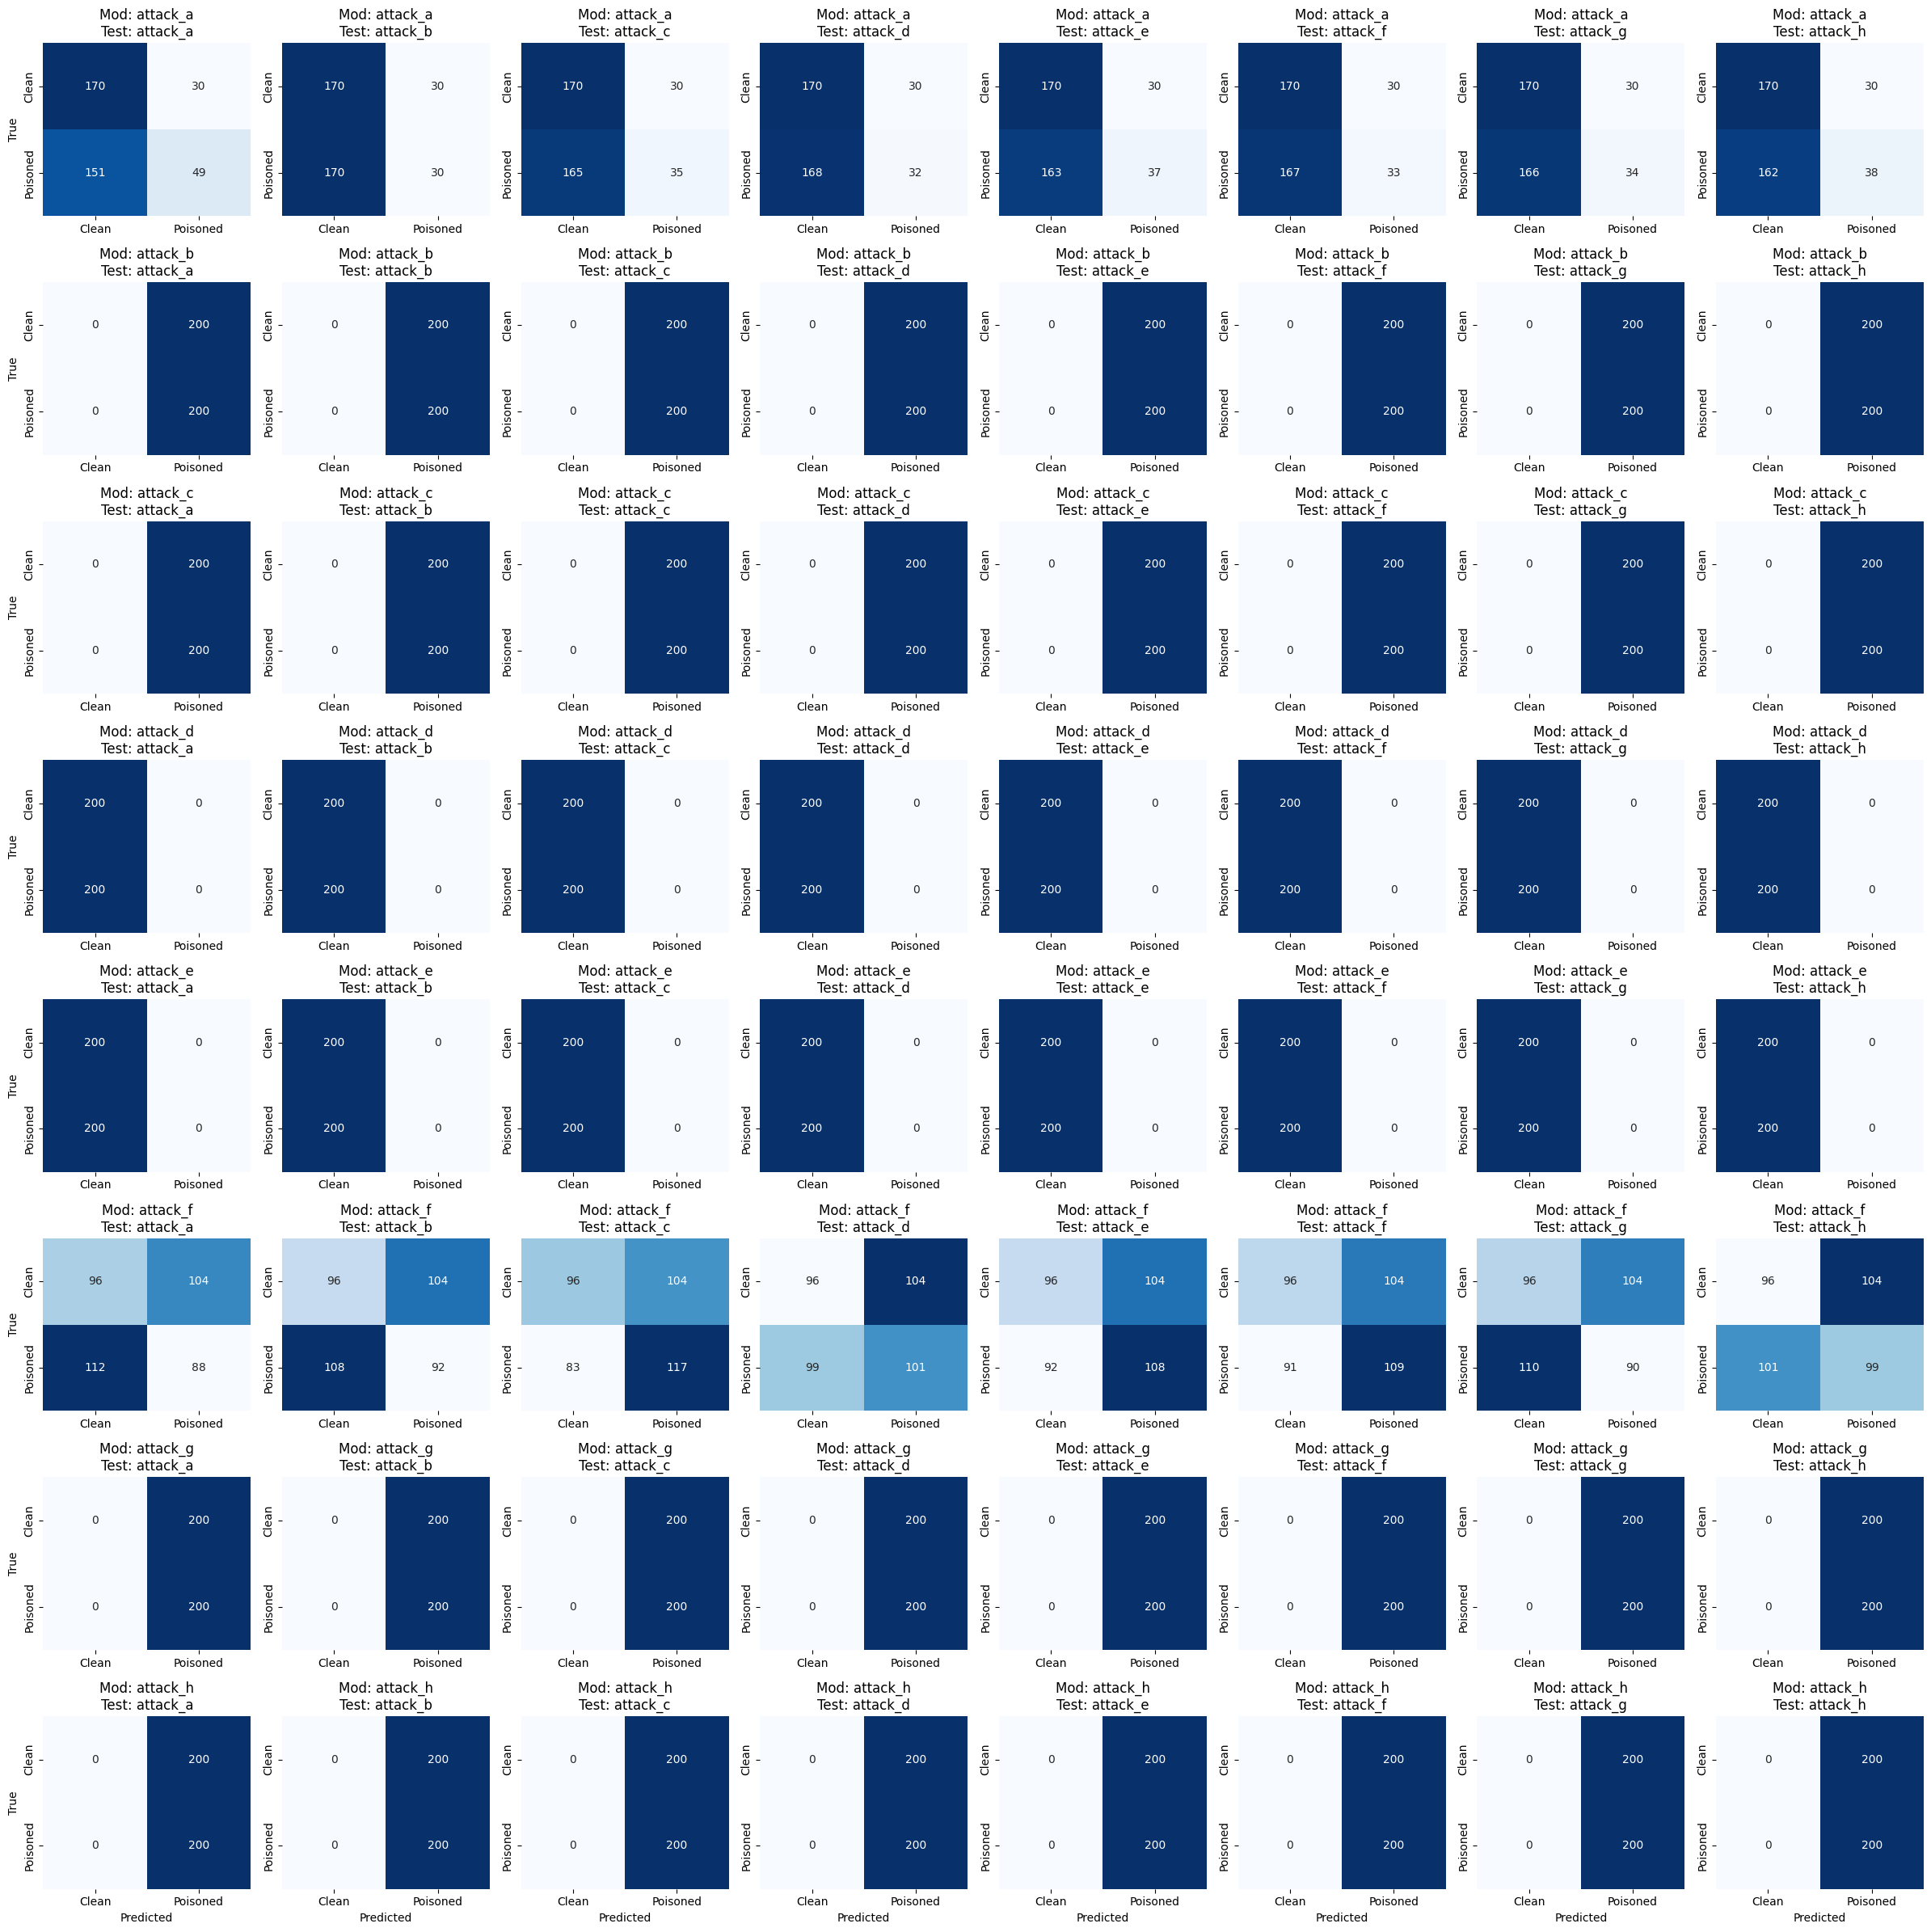

In [20]:
attacks_list = list(attack_dirs.keys())
fig, axes = plt.subplots(len(pythia_models), len(attacks_list), figsize=(3 * len(attacks_list), 3 * len(pythia_models)))

for i, (model_name, model) in enumerate(pythia_models.items()):
    model.eval()
    for j, test_attack_name in enumerate(attacks_list):
        
        # Test on clean TEST split + this specific attack TEST split
        test_ds = PythiaPathDataset(test_clean_paths, test_attack_paths[test_attack_name], transform=pythia_transforms)
        test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
        
        all_preds = []
        all_poisoned = []
        
        with torch.no_grad():
            for imgs, _, is_poisoned in test_loader:
                imgs = imgs.to(model.device)
                logits = model(imgs)
                preds = (torch.sigmoid(logits) > 0.5).long().cpu()
                
                all_preds.extend(preds.numpy())
                all_poisoned.extend(is_poisoned.numpy())
                
        cm = confusion_matrix(all_poisoned, all_preds)
        ax = axes[i, j]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                    xticklabels=['Clean', 'Poisoned'], 
                    yticklabels=['Clean', 'Poisoned'])
        
        ax.set_title(f"Mod: {model_name}\nTest: {test_attack_name}")
        if i == len(pythia_models) - 1:
            ax.set_xlabel("Predicted")
        if j == 0:
            ax.set_ylabel("True")

plt.tight_layout()
plt.show()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec,
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


--- Training Pythia model holding out (unseen): attack_a ---


...

`weights_only` was not set, defaulting to `False`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


--- Training Pythia model holding out (unseen): attack_h ---


`Trainer.fit` stopped: `max_epochs=10` reached.


`weights_only` was not set, defaulting to `False`.


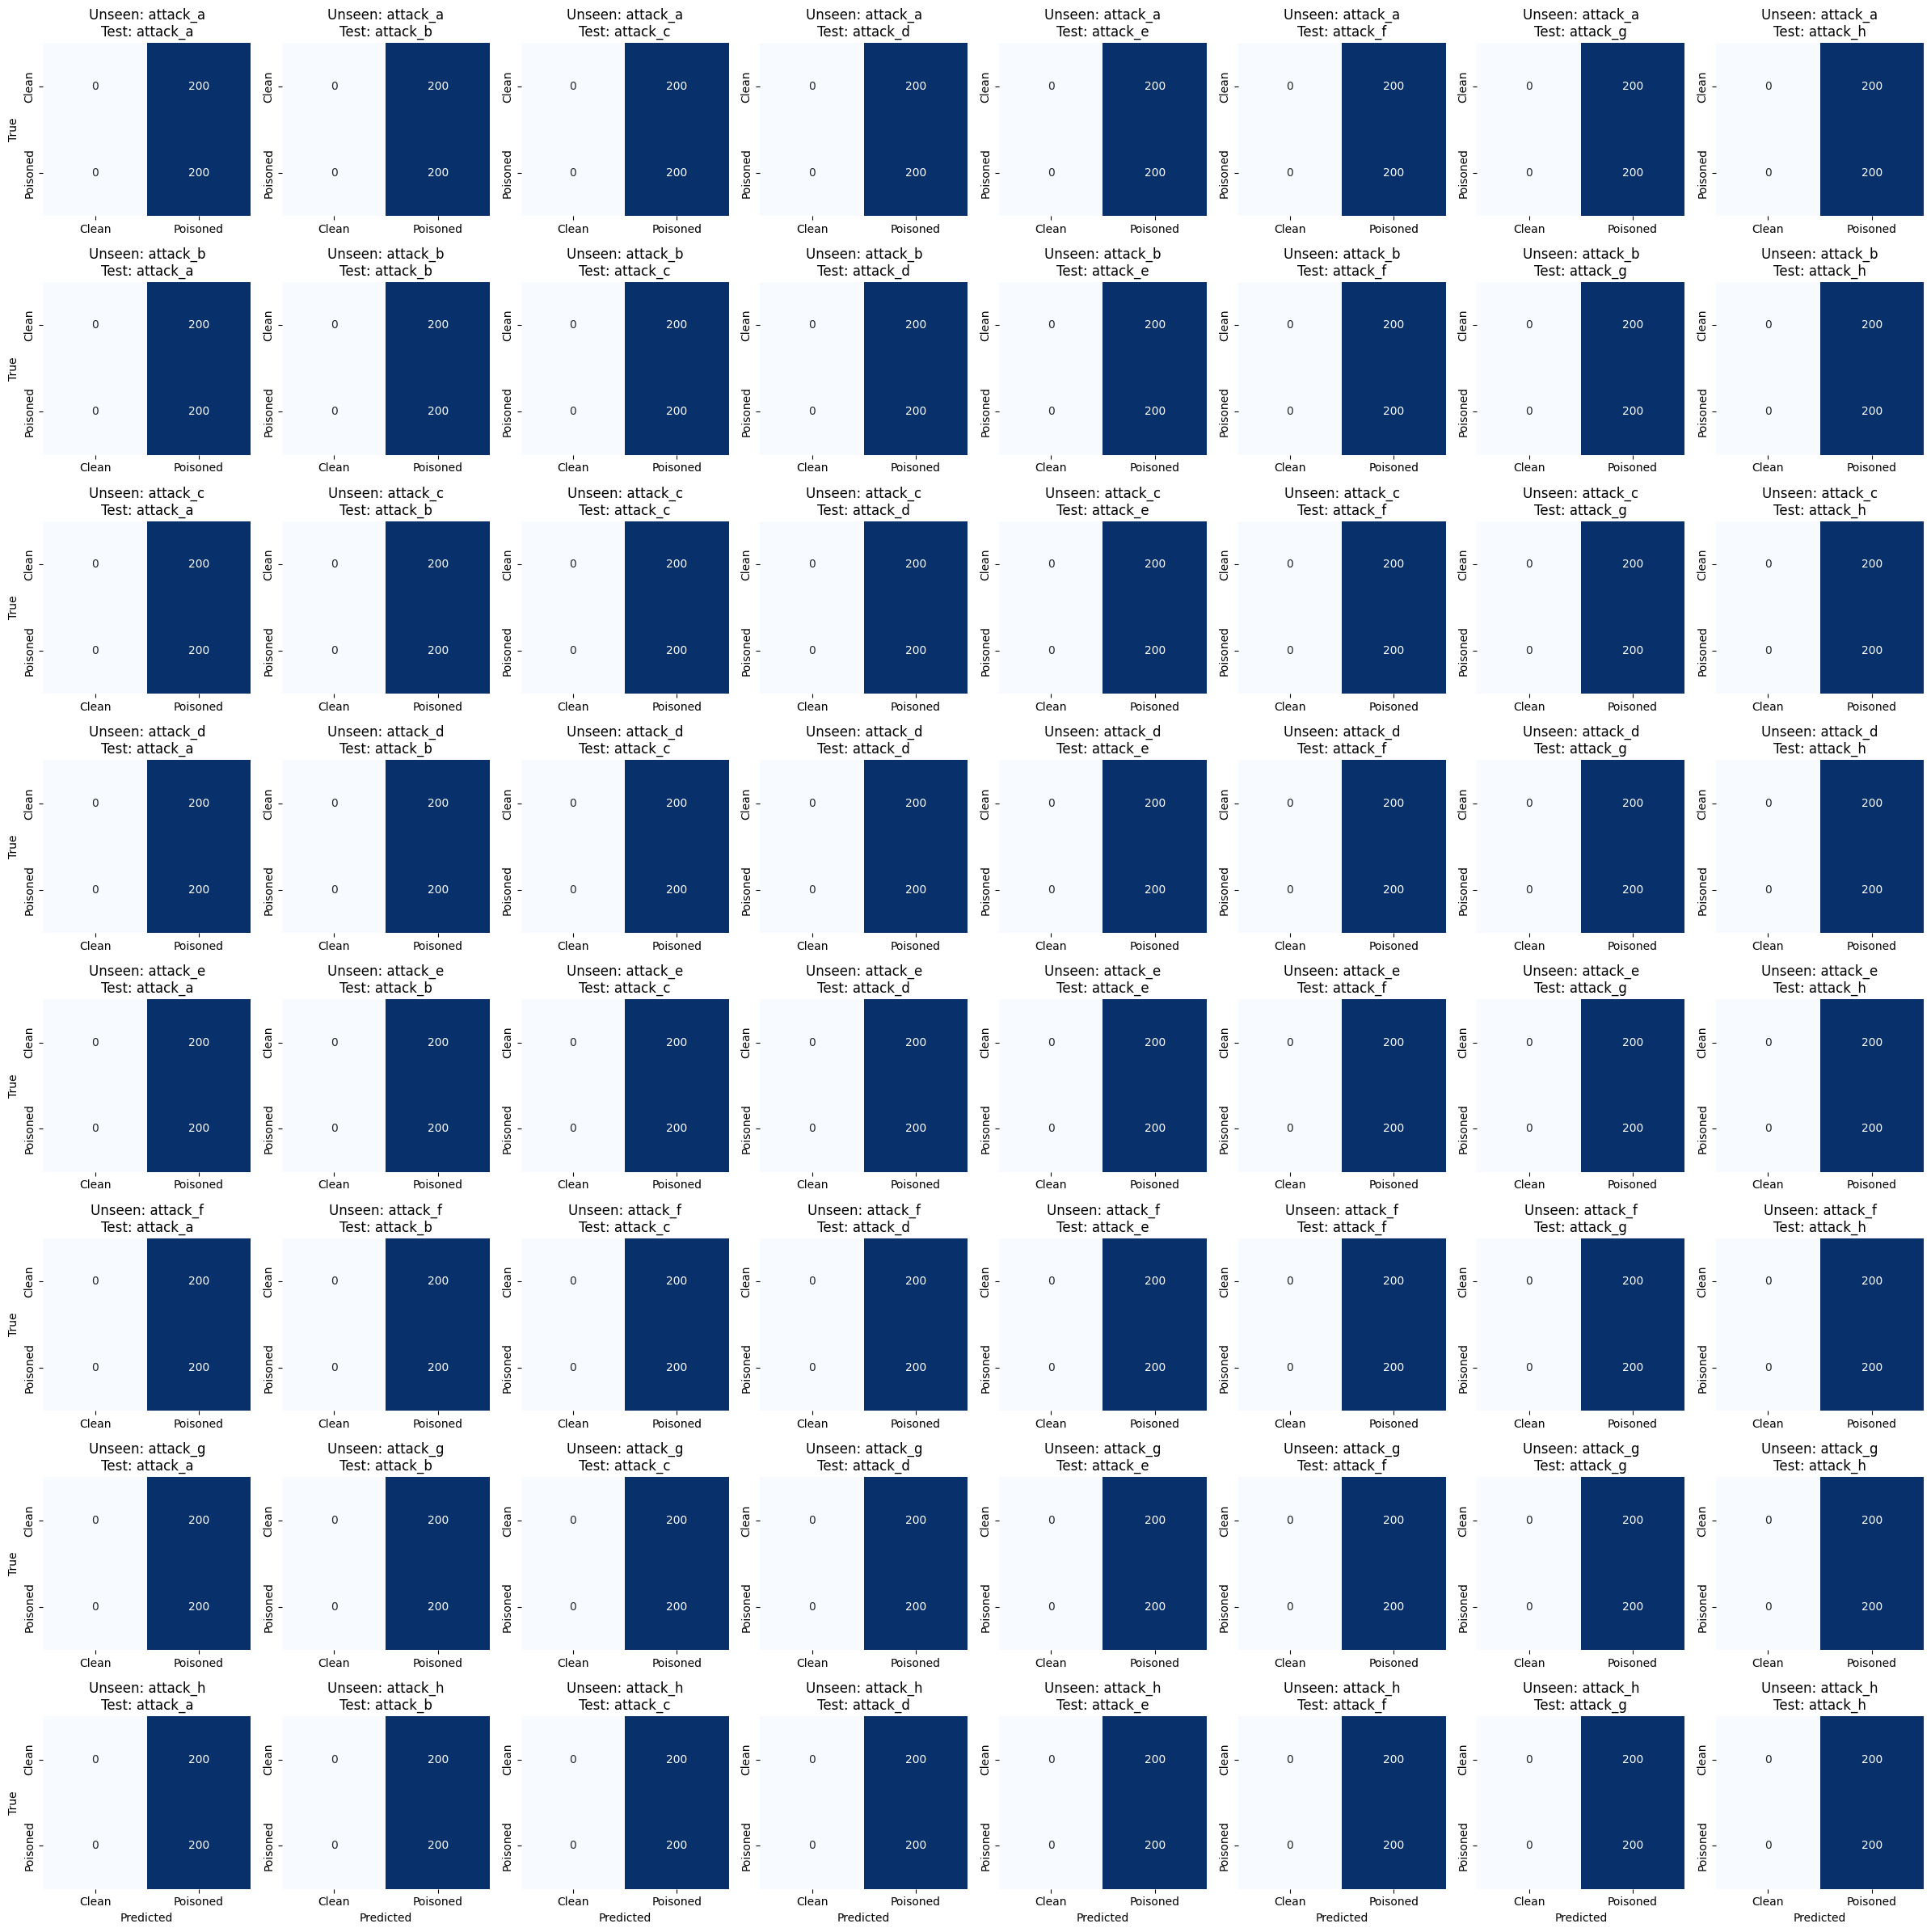

In [21]:
class MultipleAttacksPythiaPathDataset(Dataset):
    def __init__(self, clean_paths, attack_paths_dict, attack_names_list, transform=None):
        self.clean_paths = clean_paths
        self.attack_paths = []
        for name in attack_names_list:
            self.attack_paths.extend(attack_paths_dict[name])
        self.transform = transform
        
    def __len__(self):
        return len(self.clean_paths) + len(self.attack_paths)
        
    def __getitem__(self, idx):
        if idx < len(self.clean_paths):
            img_path = self.clean_paths[idx]
            is_poisoned = 0
        else:
            img_path = self.attack_paths[idx - len(self.clean_paths)]
            is_poisoned = 1
            
        img = Image.open(img_path).convert('L')
        if self.transform:
            img = self.transform(img)
            
        return img, 0, is_poisoned

mixed_pythia_models = {}
os.makedirs('saved_models', exist_ok=True)

for held_out_name in attacks_list:
    print(f"\n--- Training Pythia model holding out (unseen): {held_out_name} ---")
    
    # Get all attack names except for the held out one
    train_attack_names = [k for k in attacks_list if k != held_out_name]
    
    # Train using the global TRAIN split of clean images and the TRAIN splits of corresponding attacks
    dataset = MultipleAttacksPythiaPathDataset(train_clean_paths, train_attack_paths, train_attack_names, transform=pythia_transforms)
    
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_split, val_split = torch.utils.data.random_split(dataset, [train_size, val_size])
    
    train_loader = DataLoader(train_split, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_split, batch_size=64, shuffle=False)

    model = PoisonClassifier(lr=1e-3)
    
    trainer = Trainer(
        max_epochs=10,
        accelerator='auto',
        devices=1,
        log_every_n_steps=10,
        enable_model_summary=False,
    )

    trainer.fit(model, train_loader, val_loader)
    
    model_path = os.path.join('saved_models', f"pythia_model_mixed_no_{held_out_name}.ckpt")
    trainer.save_checkpoint(model_path)
    
    mixed_pythia_models[held_out_name] = model

# Plotting evaluation grid
fig, axes = plt.subplots(len(mixed_pythia_models), len(attacks_list), figsize=(3 * len(attacks_list), 3 * len(mixed_pythia_models)))

for i, (held_out_name, model) in enumerate(mixed_pythia_models.items()):
    model.eval()
    for j, test_attack_name in enumerate(attacks_list):
        
        # Test dataset contains global TEST clean + ONE specific test attack (TEST split)
        test_ds = PythiaPathDataset(test_clean_paths, test_attack_paths[test_attack_name], transform=pythia_transforms)
        test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
        
        all_preds = []
        all_poisoned = []
        
        with torch.no_grad():
            for imgs, _, is_poisoned in test_loader:
                imgs = imgs.to(model.device)
                logits = model(imgs)
                preds = (torch.sigmoid(logits) > 0.5).long().cpu()
                
                all_preds.extend(preds.numpy())
                all_poisoned.extend(is_poisoned.numpy())
                
        cm = confusion_matrix(all_poisoned, all_preds)
        ax = axes[i, j]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                    xticklabels=['Clean', 'Poisoned'], 
                    yticklabels=['Clean', 'Poisoned'])
        
        ax.set_title(f"Unseen: {held_out_name}\nTest: {test_attack_name}")
        
        if i == len(mixed_pythia_models) - 1:
            ax.set_xlabel("Predicted")
        if j == 0:
            ax.set_ylabel("True")

plt.tight_layout()
plt.show()